# 탑다운 백테스팅 분석

**전략 구조:**  
글로벌 매크로 신호 → WICS 섹터 선택 → FA 7지표 종목 선택

```
[1단계] 매크로 국면 (data/asset)
  구리·BDI → 경기 국면 / CPI·TNX → 금리 환경
  → A(Risk-On+저금리) / B(Risk-On+고금리) / C(Risk-Off+저금리) / D(Risk-Off+고금리)

[2단계] 섹터 선택 (WICS)
  국면별 섹터 비중 결정

[3단계] 종목 선택 (WICS + DART)
  FA 7지표 점수 상위 N개 종목 편입
```

In [1]:
import sys
sys.path.insert(0, '..')  # analysis_good593/ 를 패스에 추가

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

from backtesting.runner import run_backtest
from backtesting.strategy.macro_signal import compute_macro_signals
from backtesting.metrics import calc_metrics, plot_equity_curve, plot_monthly_heatmap, plot_drawdown
from backtesting.report import print_summary_table, plot_full_report, plot_rebalance_history

print('모듈 로딩 완료')

모듈 로딩 완료


---
## 1. 매크로 국면 시각화

In [2]:
YEARS = [2022, 2023, 2024]

macro = compute_macro_signals(YEARS)
regime_series = macro.to_series()

# 국면 분포
print('=== 국면 분포 ===')
print(regime_series.value_counts().sort_index())
print()
print('국면 의미:')
print('  A: Risk-On  + 저금리 → IT·경기소비재·산업재')
print('  B: Risk-On  + 고금리 → 에너지·소재·금융')
print('  C: Risk-Off + 저금리 → 헬스케어·유틸리티·필수소비재')
print('  D: Risk-Off + 고금리 → 필수소비재·헬스케어')

=== 국면 분포 ===
Regime.A     18
Regime.B    143
Regime.C     62
Regime.D    531
Name: count, dtype: int64

국면 의미:
  A: Risk-On  + 저금리 → IT·경기소비재·산업재
  B: Risk-On  + 고금리 → 에너지·소재·금융
  C: Risk-Off + 저금리 → 헬스케어·유틸리티·필수소비재
  D: Risk-Off + 고금리 → 필수소비재·헬스케어


---
## 2. 백테스팅 실행

### 2-1. 연도 전체

In [3]:
# 2022~2024년 전체 백테스팅 (분기별 리밸런싱)
result = run_backtest(
    year=YEARS,
    initial_cash=100_000_000,
    commission=0.00015,
    slippage=0.0005,
    verbose=True,
)

print(result.summary())

[1/4] 데이터 로딩 — 연도: [2022, 2023, 2024] | 전략: TopDown_FA_top5


[2/4] 리밸런싱 스케줄 계산
  [TopDown_FA_top5] 2022-03-31 | 국면=D | 섹터=4개 | 종목=20개
  [TopDown_FA_top5] 2022-06-30 | 국면=D | 섹터=4개 | 종목=20개
  [TopDown_FA_top5] 2022-09-30 | 국면=D | 섹터=4개 | 종목=20개
  [TopDown_FA_top5] 2022-12-29 | 국면=D | 섹터=4개 | 종목=20개


  [TopDown_FA_top5] 2023-03-31 | 국면=B | 섹터=5개 | 종목=25개
  [TopDown_FA_top5] 2023-06-30 | 국면=D | 섹터=4개 | 종목=20개
  [TopDown_FA_top5] 2023-09-27 | 국면=D | 섹터=4개 | 종목=20개


  [TopDown_FA_top5] 2023-12-28 | 국면=A | 섹터=5개 | 종목=25개
  [TopDown_FA_top5] 2024-03-29 | 국면=B | 섹터=5개 | 종목=25개
  [TopDown_FA_top5] 2024-06-28 | 국면=D | 섹터=4개 | 종목=20개


  [TopDown_FA_top5] 2024-09-30 | 국면=C | 섹터=5개 | 종목=25개
  [TopDown_FA_top5] 2024-12-30 | 국면=D | 섹터=4개 | 종목=20개
[3/4] Backtrader 피드 구성 — 후보 종목 97개


[4/4] 백테스팅 실행 중...


  [2024-03-29] 리밸런싱: 25개 종목 | 포트폴리오=100,000,000원
  [2024-06-28] 리밸런싱: 20개 종목 | 포트폴리오=103,647,392원
  ✔ 체결: 002030 PnL=339,980원
  ✔ 체결: 348950 PnL=-173,275원
  ✔ 체결: 309960 PnL=196,020원
  ✔ 체결: 069260 PnL=-52,080원
  ✔ 체결: 251970 PnL=4,158,000원
  ✔ 체결: 404990 PnL=192,000원
  ✔ 체결: 145270 PnL=-47,730원
  ✔ 체결: 090410 PnL=-430,348원
  ✔ 체결: 003300 PnL=206,190원
  ✔ 체결: 006890 PnL=219,600원
  ✔ 체결: 038010 PnL=376,740원
  ✔ 체결: 300720 PnL=269,920원
  ✔ 체결: 036190 PnL=-76,300원
  ✔ 체결: 277070 PnL=-158,840원
  ✔ 체결: 027410 PnL=-370,440원
  [2024-09-30] 리밸런싱: 25개 종목 | 포트폴리오=99,667,894원
  ✔ 체결: 006120 PnL=-994,700원
  ✔ 체결: 112610 PnL=375,000원
  ✔ 체결: 078930 PnL=-535,500원
  ✔ 체결: 054950 PnL=-1,464,750원
  ✔ 체결: 126720 PnL=-464,400원
  ✔ 체결: 137950 PnL=-1,199,450원
  [2024-12-30] 리밸런싱: 20개 종목 | 포트폴리오=93,874,440원
  전략: TopDown_FA_top5
  초기 자본:        100,000,000 원
  최종 자산:         93,874,440 원
  총 수익률:            -6.13%
  CAGR:                 -2.14%
  MDD:                 -15.45%
  Sharpe:                -0.47
 

### 2-2. 특정 분기

In [4]:
# 2023년 Q3 (7~9월) 백테스팅
result_q = run_backtest(
    year=2023,
    quarter=3,
    initial_cash=100_000_000,
    verbose=True,
)
print(result_q.summary())

[1/4] 데이터 로딩 — 연도: [2023] | 전략: TopDown_FA_top5


[2/4] 리밸런싱 스케줄 계산
  [TopDown_FA_top5] 2023-09-27 | 국면=D | 섹터=4개 | 종목=20개
[3/4] Backtrader 피드 구성 — 후보 종목 20개


[4/4] 백테스팅 실행 중...
  [2023-09-27] 리밸런싱: 20개 종목 | 포트폴리오=100,000,000원


  전략: TopDown_FA_top5
  초기 자본:        100,000,000 원
  최종 자산:         99,666,914 원
  총 수익률:            -0.33%
  CAGR:                 -0.34%
  MDD:                  -5.86%
  Sharpe:                -0.46
  Sortino:               -0.31
  Calmar:                 0.06


### 2-3. 특정 월

In [5]:
# 2024년 11월 백테스팅
result_m = run_backtest(
    year=2024,
    month=11,
    initial_cash=100_000_000,
    verbose=True,
)
print(result_m.summary())

[1/4] 데이터 로딩 — 연도: [2024] | 전략: TopDown_FA_top5


[2/4] 리밸런싱 스케줄 계산
  [TopDown_FA_top5] 2024-11-29 | 국면=D | 섹터=4개 | 종목=20개
[3/4] Backtrader 피드 구성 — 후보 종목 20개


[4/4] 백테스팅 실행 중...


  [2024-11-29] 리밸런싱: 20개 종목 | 포트폴리오=100,000,000원
  전략: TopDown_FA_top5
  초기 자본:        100,000,000 원
  최종 자산:        100,043,107 원
  총 수익률:             0.04%
  CAGR:                  0.04%
  MDD:                  -7.72%
  Sharpe:                -0.33
  Sortino:               -0.16
  Calmar:                 0.01


---
## 3. 성과 분석

In [6]:
# 전략 vs 벤치마크 요약 테이블
print_summary_table(result)

----------------------------------------------
지표                       탑다운 전략       KOSPI 벤치마크
----------------------------------------------
총 수익률                    -6.13%          -16.35%
CAGR                     -2.14%           -5.94%
MDD                     -15.45%          -27.78%
Sharpe                    -0.47            -0.39
Sortino                   -0.28            -0.54
Calmar                     0.14             0.21
----------------------------------------------


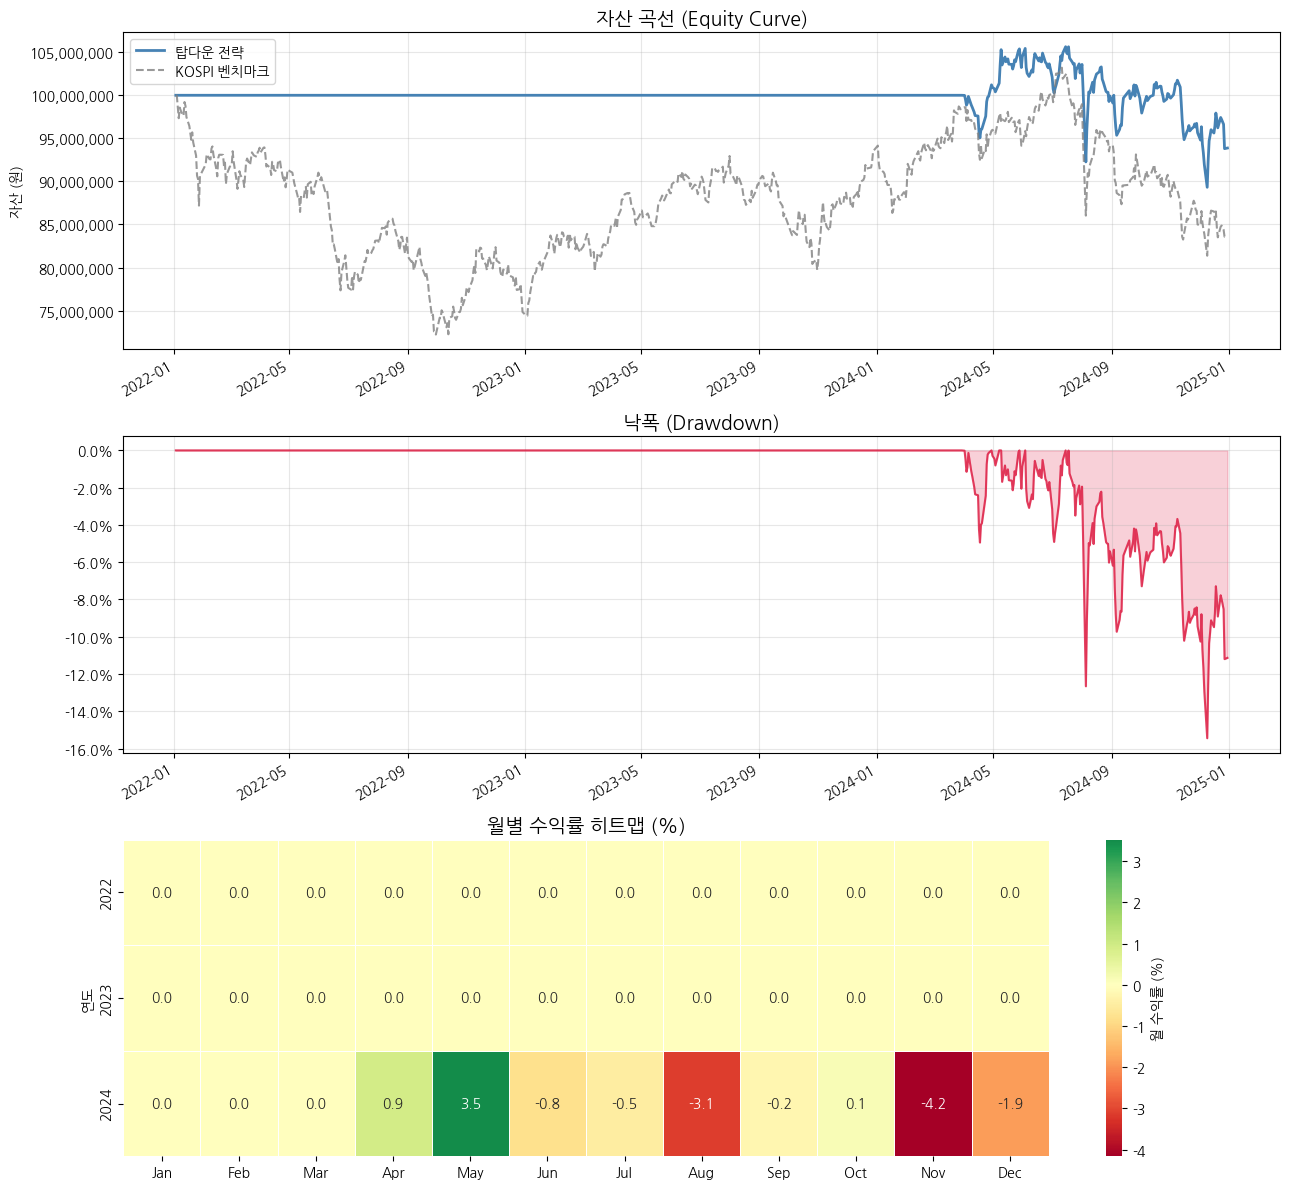

In [7]:
# 자산 곡선
fig, axes = plt.subplots(3, 1, figsize=(13, 12))
plot_equity_curve(result.time_returns, result.benchmark_returns, result.initial_cash, ax=axes[0])
plot_drawdown(result.time_returns, ax=axes[1])
plot_monthly_heatmap(result.time_returns, ax=axes[2])
plt.tight_layout()
plt.show()

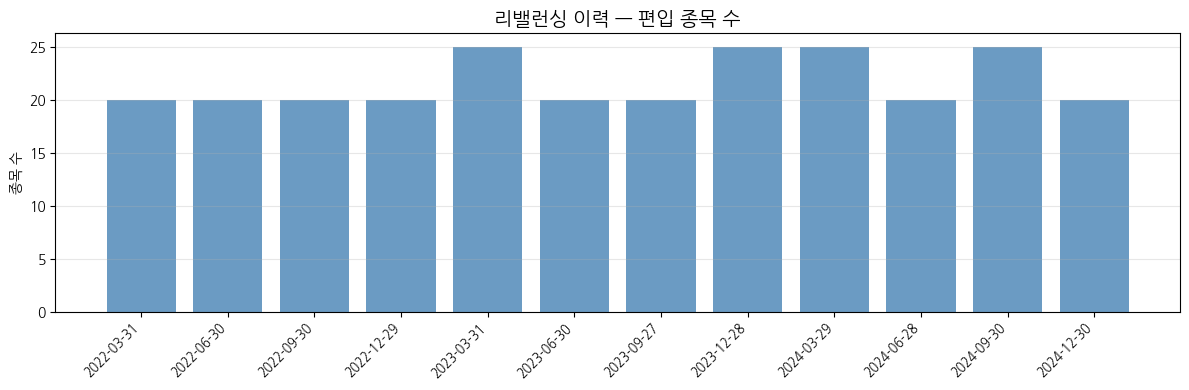

In [8]:
# 리밸런싱 이력
fig = plot_rebalance_history(result)
plt.show()

---
## 4. 전체 리포트 (대시보드)

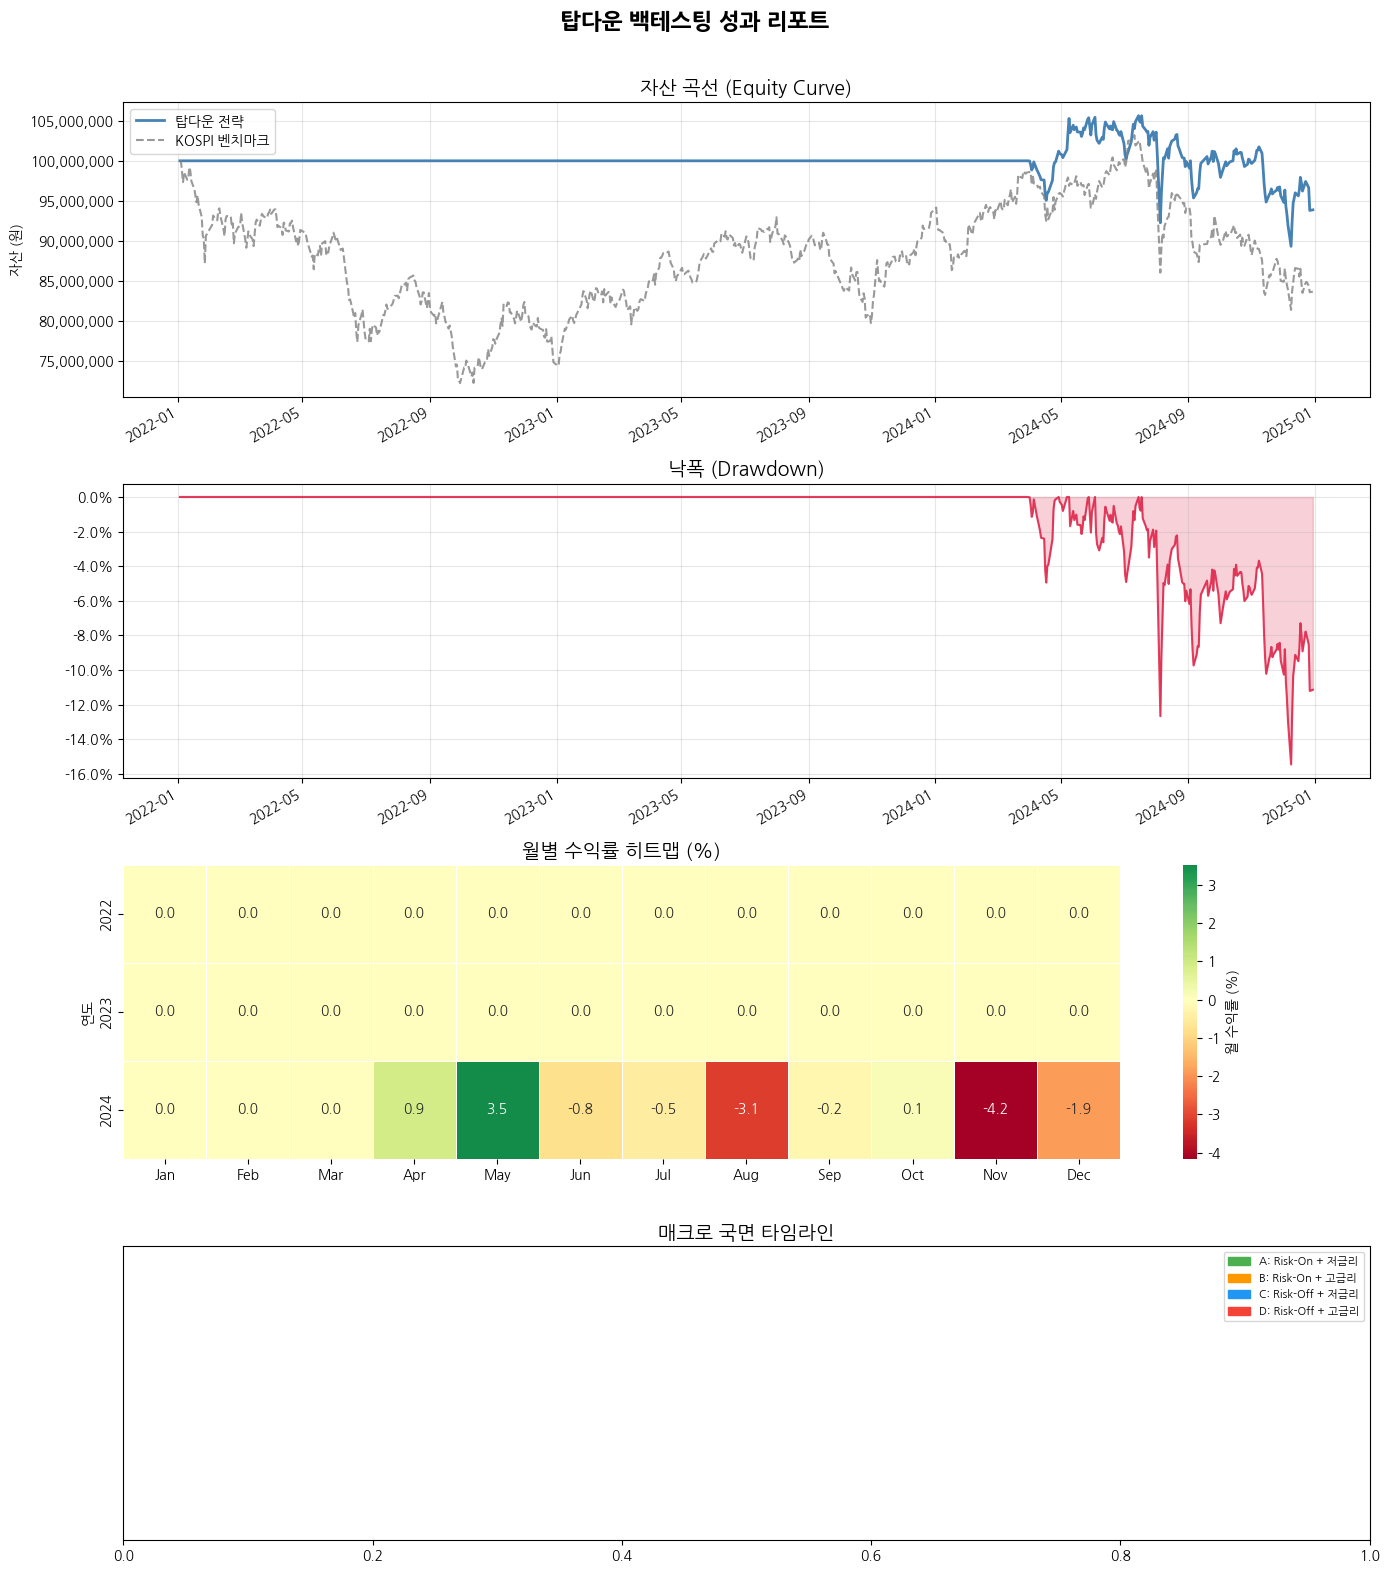

In [9]:
fig = plot_full_report(result, macro_signal=macro)
plt.show()

---
## 5. 리밸런싱 날짜별 포트폴리오 확인

In [10]:
for rebal_date, weights in sorted(result.rebalance_schedule.items()):
    print(f'\n=== {rebal_date} ===')
    for cmp_cd, w in sorted(weights.items(), key=lambda x: -x[1]):
        print(f'  {cmp_cd}: {w:.2%}')


=== 2022-03-31 ===
  250000: 6.93%
  001800: 6.93%
  073560: 6.93%
  009780: 6.93%
  271560: 6.93%
  228850: 5.94%
  206640: 5.94%
  016580: 5.94%
  008490: 5.94%
  084110: 5.94%
  051600: 3.96%
  034590: 3.96%
  038870: 3.96%
  267290: 3.96%
  015360: 3.96%
  012320: 2.97%
  003650: 2.97%
  078930: 2.97%
  013810: 2.97%
  010950: 2.97%

=== 2022-06-30 ===
  250000: 6.93%
  009780: 6.93%
  001800: 6.93%
  073560: 6.93%
  004590: 6.93%
  206640: 5.94%
  243070: 5.94%
  016580: 5.94%
  084110: 5.94%
  008490: 5.94%
  130660: 3.96%
  051600: 3.96%
  015360: 3.96%
  267290: 3.96%
  034590: 3.96%
  003650: 2.97%
  010950: 2.97%
  078930: 2.97%
  012320: 2.97%
  013810: 2.97%

=== 2022-09-30 ===
  001800: 6.93%
  250000: 6.93%
  073560: 6.93%
  009780: 6.93%
  208140: 6.93%
  206640: 5.94%
  008490: 5.94%
  084110: 5.94%
  208370: 5.94%
  200130: 5.94%
  051600: 3.96%
  034590: 3.96%
  130660: 3.96%
  015360: 3.96%
  267290: 3.96%
  010950: 2.97%
  003650: 2.97%
  078930: 2.97%
  012320: 2.

---
## 6. 파이프라인 API 사용 예제

리팩토링 후 각 단계를 **독립적으로 교체·수정·비교**할 수 있다.

```
TopDownPipeline
  ├── macro_signal    (1단계) → BdiCopperMacroSignal 또는 직접 구현
  ├── sector_selector (2단계) → RegimeBasedSectorSelector 또는 직접 구현
  └── stock_scorer    (3단계) → FaStockScorer 또는 직접 구현
```

In [11]:
from backtesting.runner import run_backtest, compare_backtests
from backtesting.strategy.pipeline import TopDownPipeline, default_pipeline
from backtesting.strategy.macro_signal import BdiCopperMacroSignal, Regime
from backtesting.strategy.sector_selector import RegimeBasedSectorSelector
from backtesting.strategy.stock_scorer import FaStockScorer

print("파이프라인 API 로딩 완료")

파이프라인 API 로딩 완료


### 6-1. 파이프라인 명시적 구성

`default_pipeline()` 은 편의 함수다.  
직접 구성하면 각 단계 파라미터를 세밀하게 제어할 수 있다.

In [12]:
# 방법 1: default_pipeline() — 기본 설정
pipeline_default = default_pipeline(top_n=5)

# 방법 2: 단계별 명시적 구성 (위와 동일한 결과)
pipeline_explicit = TopDownPipeline(
    macro_signal    = BdiCopperMacroSignal(),
    sector_selector = RegimeBasedSectorSelector(),
    stock_scorer    = FaStockScorer(top_n=5),
    name            = "TopDown_FA_top5",
)

result_default = run_backtest(year=YEARS, pipeline=pipeline_default)
print(result_default.summary())

[1/4] 데이터 로딩 — 연도: [2022, 2023, 2024] | 전략: TopDown_FA_top5


[2/4] 리밸런싱 스케줄 계산


[3/4] Backtrader 피드 구성 — 후보 종목 97개


[4/4] 백테스팅 실행 중...


  전략: TopDown_FA_top5
  초기 자본:        100,000,000 원
  최종 자산:         93,874,440 원
  총 수익률:            -6.13%
  CAGR:                 -2.14%
  MDD:                 -15.45%
  Sharpe:                -0.47
  Sortino:               -0.28
  Calmar:                 0.14


### 6-2. 파라미터 튜닝

각 단계의 파라미터만 바꿔서 전략 효과를 실험할 수 있다.

| 파라미터 | 위치 | 설명 |
|---|---|---|
| `ma_window` | BdiCopperMacroSignal | 이동평균 기간 (기본 63일 ≈ 3개월) |
| `high_rate_tnx` | BdiCopperMacroSignal | 고금리 판단 TNX 기준 (기본 4.0%) |
| `high_rate_cpi` | BdiCopperMacroSignal | 고금리 판단 CPI 기준 (기본 4.0%) |
| `weights_table` | RegimeBasedSectorSelector | 국면별 섹터 비중 테이블 교체 |
| `top_n` | FaStockScorer | 섹터당 편입 종목 수 (기본 5개) |

In [13]:
# 1단계 파라미터 튜닝: 금리 기준을 3%로 낮춤 (더 빨리 고금리 국면으로 전환)
pipeline_low_rate = TopDownPipeline(
    macro_signal    = BdiCopperMacroSignal(high_rate_tnx=3.0, high_rate_cpi=3.0),
    sector_selector = RegimeBasedSectorSelector(),
    stock_scorer    = FaStockScorer(top_n=5),
    name            = "LowRateThreshold_3pct",
)

# 1단계 파라미터 튜닝: MA 기간을 6개월(126일)로 늘려 노이즈 감소
pipeline_slow_ma = TopDownPipeline(
    macro_signal    = BdiCopperMacroSignal(ma_window=126, slope_window=42),
    sector_selector = RegimeBasedSectorSelector(),
    stock_scorer    = FaStockScorer(top_n=5),
    name            = "SlowMA_6M",
)

# 3단계 파라미터 튜닝: 섹터당 3종목 (집중 투자)
pipeline_top3 = TopDownPipeline(
    macro_signal    = BdiCopperMacroSignal(),
    sector_selector = RegimeBasedSectorSelector(),
    stock_scorer    = FaStockScorer(top_n=3),
    name            = "TopDown_FA_top3",
)

print("파이프라인 구성 완료")
print(f"  - {pipeline_low_rate.name}")
print(f"  - {pipeline_slow_ma.name}")
print(f"  - {pipeline_top3.name}")

파이프라인 구성 완료
  - LowRateThreshold_3pct
  - SlowMA_6M
  - TopDown_FA_top3


### 6-3. 전략 비교 (`compare_backtests`)

여러 파이프라인을 동일 기간·동일 자본으로 한번에 실행해 성과를 비교한다.  
데이터 로딩은 한 번만 수행한다.

In [14]:
results = compare_backtests(
    pipelines=[
        default_pipeline(top_n=5),   # 기본 전략
        pipeline_top3,               # 집중 투자 (섹터당 3종목)
        pipeline_low_rate,           # 금리 기준 완화
        pipeline_slow_ma,            # 느린 MA (노이즈 감소)
    ],
    year=YEARS,
    initial_cash=100_000_000,
)

# 각 전략 결과 출력
for r in results:
    print(r.summary())

[비교 백테스팅] 전략 4개: ['TopDown_FA_top5', 'TopDown_FA_top3', 'LowRateThreshold_3pct', 'SlowMA_6M']
[1/3] 데이터 로딩 — 연도: [2022, 2023, 2024]



[1/4] 전략 실행: TopDown_FA_top5



[2/4] 전략 실행: TopDown_FA_top3



[3/4] 전략 실행: LowRateThreshold_3pct



[4/4] 전략 실행: SlowMA_6M


  전략: TopDown_FA_top5
  초기 자본:        100,000,000 원
  최종 자산:         93,874,440 원
  총 수익률:            -6.13%
  CAGR:                 -2.14%
  MDD:                 -15.45%
  Sharpe:                -0.47
  Sortino:               -0.28
  Calmar:                 0.14
  전략: TopDown_FA_top3
  초기 자본:        100,000,000 원
  최종 자산:         95,913,335 원
  총 수익률:            -4.09%
  CAGR:                 -1.42%
  MDD:                 -14.42%
  Sharpe:                -0.32
  Sortino:               -0.20
  Calmar:                 0.10
  전략: LowRateThreshold_3pct
  초기 자본:        100,000,000 원
  최종 자산:         93,146,947 원
  총 수익률:            -6.85%
  CAGR:                 -2.40%
  MDD:                 -16.74%
  Sharpe:                -0.49
  Sortino:               -0.30
  Calmar:                 0.14
  전략: SlowMA_6M
  초기 자본:        100,000,000 원
  최종 자산:         94,300,860 원
  총 수익률:            -5.70%
  CAGR:                 -1.99%
  MDD:                 -14.88%
  Sharpe:                -0.49
  Sort

In [15]:
from backtesting.metrics import calc_metrics

# 전략 비교 요약 테이블
metrics_rows = []
for r in results:
    m = calc_metrics(r.time_returns, r.initial_cash, r.final_value)
    metrics_rows.append({
        "전략":      r.pipeline_name,
        "총수익률":  f"{m['total_return']:.2%}",
        "CAGR":     f"{m['cagr']:.2%}",
        "MDD":      f"{m['mdd']:.2%}",
        "Sharpe":   f"{m['sharpe']:.2f}",
        "Sortino":  f"{m['sortino']:.2f}",
        "Calmar":   f"{m['calmar']:.2f}",
    })

df_compare = pd.DataFrame(metrics_rows).set_index("전략")
df_compare

,총수익률,CAGR,MDD,Sharpe,Sortino,Calmar
전략,,,,,,
TopDown_FA_top5,-6.13%,-2.14%,-15.45%,-0.47,-0.28,0.14
TopDown_FA_top3,-4.09%,-1.42%,-14.42%,-0.32,-0.20,0.10
LowRateThreshold_3pct,-6.85%,-2.40%,-16.74%,-0.49,-0.30,0.14
SlowMA_6M,-5.70%,-1.99%,-14.88%,-0.49,-0.28,0.13


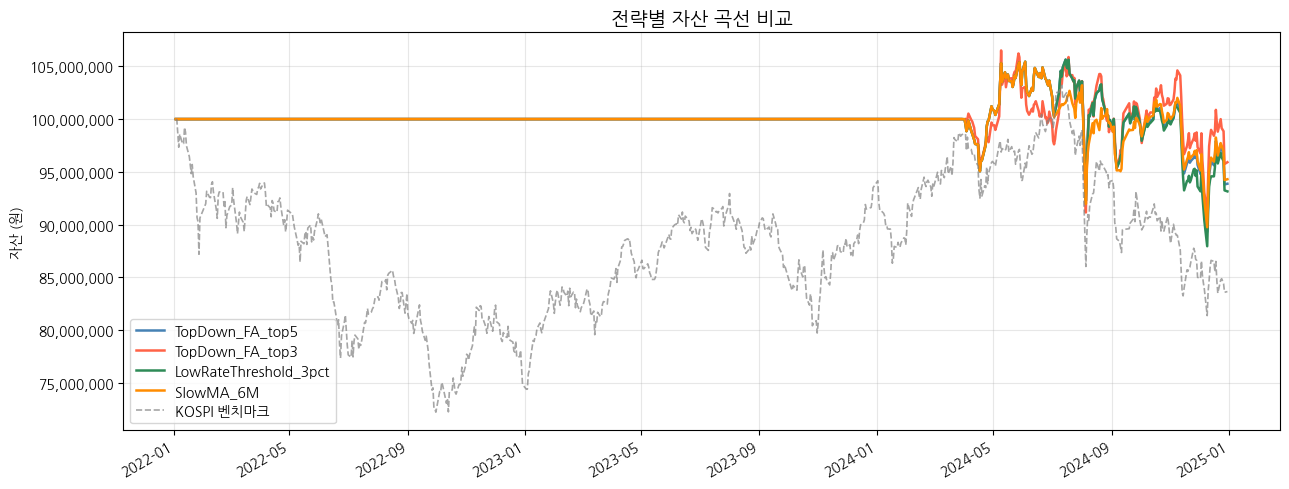

In [16]:
# 자산 곡선 오버레이 비교
fig, ax = plt.subplots(figsize=(13, 5))

colors = ["steelblue", "tomato", "seagreen", "darkorange"]
for r, color in zip(results, colors):
    cum = (1 + r.time_returns).cumprod() * r.initial_cash
    cum.plot(ax=ax, label=r.pipeline_name, linewidth=1.8, color=color)

# 벤치마크
bm = results[0].benchmark_returns.reindex(results[0].time_returns.index, method="ffill").fillna(0)
cum_bm = (1 + bm).cumprod() * results[0].initial_cash
cum_bm.plot(ax=ax, label="KOSPI 벤치마크", linewidth=1.2, linestyle="--", color="gray", alpha=0.7)

import matplotlib.ticker as mticker
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_title("전략별 자산 곡선 비교", fontsize=14)
ax.set_ylabel("자산 (원)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6-4. 2단계 섹터 비중 커스터마이징

`RegimeBasedSectorSelector` 에 다른 `weights_table` 을 주입해  
섹터 배분 로직 자체를 교체할 수 있다.

In [17]:
# IT 집중형 커스텀 섹터 비중 테이블
it_focus_weights = {
    Regime.A: {"G45": 0.60, "G25": 0.25, "G50": 0.15},          # Risk-On+저금리 → IT 집중
    Regime.B: {"G10": 0.30, "G15": 0.30, "G40": 0.20, "G20": 0.20},  # Risk-On+고금리
    Regime.C: {"G35": 0.40, "G55": 0.30, "G30": 0.30},           # Risk-Off+저금리
    Regime.D: {"G30": 0.40, "G35": 0.35, "G55": 0.25},           # Risk-Off+고금리
}

pipeline_it_focus = TopDownPipeline(
    macro_signal    = BdiCopperMacroSignal(),
    sector_selector = RegimeBasedSectorSelector(weights_table=it_focus_weights),
    stock_scorer    = FaStockScorer(top_n=5),
    name            = "IT_Focus",
)

result_it = run_backtest(year=YEARS, pipeline=pipeline_it_focus)
print(result_it.summary())

[1/4] 데이터 로딩 — 연도: [2022, 2023, 2024] | 전략: IT_Focus


[2/4] 리밸런싱 스케줄 계산


[3/4] Backtrader 피드 구성 — 후보 종목 86개


[4/4] 백테스팅 실행 중...


  전략: IT_Focus
  초기 자본:        100,000,000 원
  최종 자산:         96,848,760 원
  총 수익률:            -3.15%
  CAGR:                 -1.09%
  MDD:                 -15.63%
  Sharpe:                -0.35
  Sortino:               -0.21
  Calmar:                 0.07


### 6-5. 완전히 새로운 전략 단계 구현

`BaseStockScorer` 를 상속해 **시가총액 가중 종목 선택기**를 구현하는 예시.  
`BaseMacroSignal`, `BaseSectorSelector` 도 같은 방식으로 교체할 수 있다.

In [18]:
from backtesting.strategy.base import BaseStockScorer

class MarketCapScorer(BaseStockScorer):
    """시가총액 상위 N종목을 균등 비중으로 편입하는 단순 전략.

    FA 점수 대신 시가총액 기준으로 종목을 선택한다.
    BaseStockScorer 를 상속하므로 TopDownPipeline 에 바로 교체 적용 가능.
    """

    def __init__(self, top_n: int = 5) -> None:
        self.top_n = top_n

    def score(self, date, sector_weights, wics_df, fa_df) -> dict:
        snap = wics_df[wics_df["DATE"] <= date]
        if snap.empty:
            return {}
        snapshot = snap[snap["DATE"] == snap["DATE"].max()]

        result = {}
        for sec_cd, sec_weight in sector_weights.items():
            sec_stocks = (
                snapshot[snapshot["SEC_CD"] == sec_cd]
                .nlargest(self.top_n, "MKT_VAL")
            )
            if sec_stocks.empty:
                continue
            per_stock = sec_weight / len(sec_stocks)
            for _, row in sec_stocks.iterrows():
                result[row["CMP_CD"]] = per_stock

        total = sum(result.values())
        if total > 0:
            result = {k: v * 0.99 / total for k, v in result.items()}
        return result


# 3단계만 시가총액 선택기로 교체
pipeline_mktcap = TopDownPipeline(
    macro_signal    = BdiCopperMacroSignal(),
    sector_selector = RegimeBasedSectorSelector(),
    stock_scorer    = MarketCapScorer(top_n=5),   # ← 교체된 단계
    name            = "TopDown_MktCap",
)

result_mktcap = run_backtest(year=YEARS, pipeline=pipeline_mktcap)
print(result_mktcap.summary())

[1/4] 데이터 로딩 — 연도: [2022, 2023, 2024] | 전략: TopDown_MktCap


[2/4] 리밸런싱 스케줄 계산


[3/4] Backtrader 피드 구성 — 후보 종목 61개


[4/4] 백테스팅 실행 중...


  전략: TopDown_MktCap
  초기 자본:        100,000,000 원
  최종 자산:        119,658,591 원
  총 수익률:            19.66%
  CAGR:                  6.35%
  MDD:                 -10.71%
  Sharpe:                 0.27
  Sortino:                0.39
  Calmar:                 0.59


In [19]:
# FA vs 시가총액 최종 비교
final_results = compare_backtests(
    pipelines=[
        default_pipeline(top_n=5),
        pipeline_mktcap,
    ],
    year=YEARS,
)

rows = []
for r in final_results:
    m = calc_metrics(r.time_returns, r.initial_cash, r.final_value)
    rows.append({"전략": r.pipeline_name, **{k: f"{v:.2%}" if k != "sharpe" and k != "sortino" and k != "calmar" else f"{v:.2f}" for k, v in m.items()}})

pd.DataFrame(rows).set_index("전략")

[비교 백테스팅] 전략 2개: ['TopDown_FA_top5', 'TopDown_MktCap']
[1/3] 데이터 로딩 — 연도: [2022, 2023, 2024]



[1/2] 전략 실행: TopDown_FA_top5



[2/2] 전략 실행: TopDown_MktCap


,total_return,cagr,mdd,sharpe,sortino,calmar
전략,,,,,,
TopDown_FA_top5,-6.13%,-2.14%,-15.45%,-0.47,-0.28,0.14
TopDown_MktCap,19.66%,6.35%,-10.71%,0.27,0.39,0.59
